# Outline
- Use Univariate and Multivariate Techniques to identify Outliers

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
houses = pd.read_csv('C:/Users/Wajih/Work (DataScience)/CAPSTONE PROJECTS/Real Estate Project/Zameen.com/EDA/houses.csv',index_col=0)

In [3]:
houses.drop(columns=['Community Swimming Pool', 'Community Gym', 'Sauna',
       'Jacuzzi', 'Security Staff', 'Maintenance Staff',
       'Facilities for Disabled', 'Laundry or Dry Cleaning Facility',
       'Communal/Shared Kitchen','Lobby in Building', 'Elevators',
       'Service Elevators in Building','Floor in Building'],inplace=True)

In [4]:
houses.info() 

<class 'pandas.DataFrame'>
Index: 2080 entries, 0 to 2865
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Type                                   2080 non-null   str    
 1   Price(Cr)                              2080 non-null   float64
 2   Bath(s)                                2041 non-null   float64
 3   Area(Marla)                            2080 non-null   float64
 4   Bedroom(s)                             2049 non-null   float64
 5   Location                               2080 non-null   str    
 6   Description                            2080 non-null   str    
 7   Amenities: Main Features               1943 non-null   str    
 8   Amenities: Rooms                       1912 non-null   str    
 9   Amenities: Business and Communication  1831 non-null   str    
 10  Amenities: Community Features          1824 non-null   str    
 11  Amenities: Healthcar

In [5]:
print('Houses Duplicated',houses.duplicated().sum())

Houses Duplicated 0


## Univariate Outlier Detection
- Z Score --> for Normal Distributions
- IQR --> for Non Normal Distributions

### Price

<Axes: ylabel='Price(Cr)'>

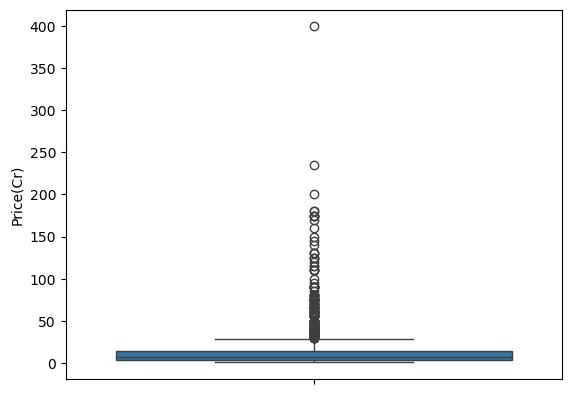

In [7]:
sns.boxplot(houses['Price(Cr)'])

In [19]:
# Analyzing the rows where Price > 150 Cr
print('Shape of Houses having Price greater than 100 Cr : ',houses[houses['Price(Cr)']>100].shape[0])
houses[houses['Price(Cr)']>100][['Location', 'Price(Cr)', 'Area(Marla)']].sort_values(by='Price(Cr)', ascending=False)

Shape of Houses having Price greater than 100 Cr :  27


,Location,Price(Cr),Area(Marla)
863,F-7,400.0,80.0
289,F-6,235.0,78.0
2399,F-6,200.0,80.0
1622,F-6,180.0,80.0
1851,F-7,180.0,80.0
1303,F-6,175.0,100.0
2052,F-7,175.0,80.0
1681,F-6,175.0,76.0
292,F-8,175.0,80.0
1564,F-7,170.0,80.0


In [20]:
# All rows included
houses.groupby('Location')['Price(Cr)'].mean().sort_values(ascending=False).head(10)

Location
E-7             73.818182
F-7             64.196970
F-6             63.956522
G-6             46.290000
F-8             45.905000
G-7             40.000000
F-10            26.782456
F-11            18.602632
Park Enclave    17.333333
Eighteen        16.644000
Name: Price(Cr), dtype: float64

In [21]:
# All rows except the rows where Price > 100 Cr
houses[houses['Price(Cr)']<100].groupby('Location')['Price(Cr)'].mean().sort_values(ascending=False).head(10)

Location
E-7             71.142857
F-7             48.741379
F-8             43.716949
G-7             40.000000
G-6             39.211111
F-6             36.980769
F-10            26.782456
F-11            18.602632
Park Enclave    17.333333
Eighteen        16.644000
Name: Price(Cr), dtype: float64

*Although F-6, F-8, F-10, G-6, E-7 etc are high cost sectors, but removing outliers still has the same distribution. So we will drop them*

In [22]:
houses = houses[~(houses['Price(Cr)']>=100)]

In [23]:
houses.shape

(2052, 28)

<Axes: ylabel='Price(Cr)'>

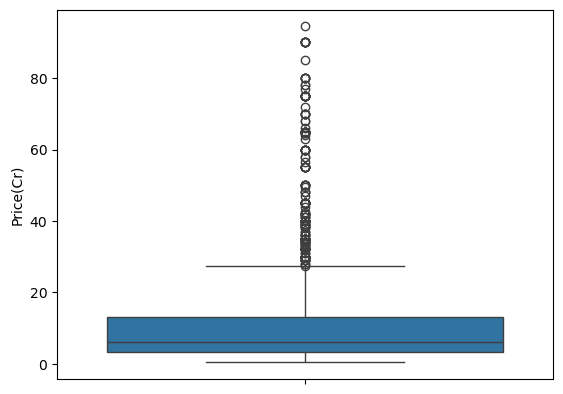

In [24]:
sns.boxplot(houses['Price(Cr)'])

<Axes: ylabel='Price(Cr)'>

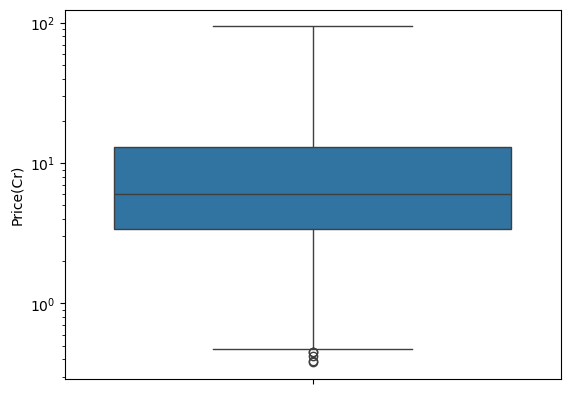

In [26]:
# Now the Price column is normal (it could be beneficial for Predciting)
sns.boxplot(houses['Price(Cr)'],log_scale=True)

In [12]:
# Area(Marla)

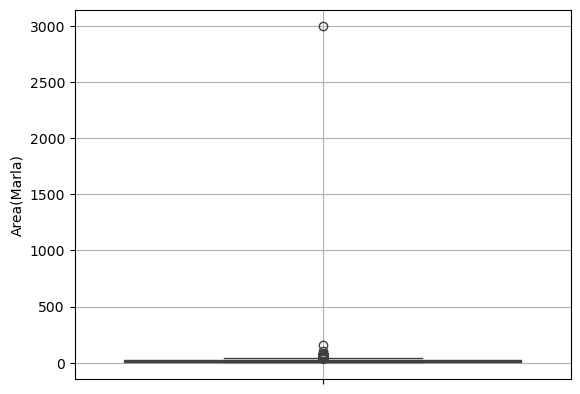

In [27]:
sns.boxplot(houses['Area(Marla)'])
plt.grid()

In [28]:
# Removed the Obvious Outlier
houses = houses[houses['Area(Marla)'] != houses['Area(Marla)'].max()]

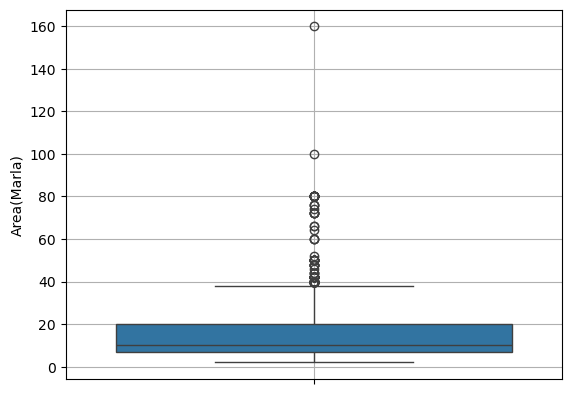

In [29]:
sns.boxplot(houses['Area(Marla)'])
plt.grid()

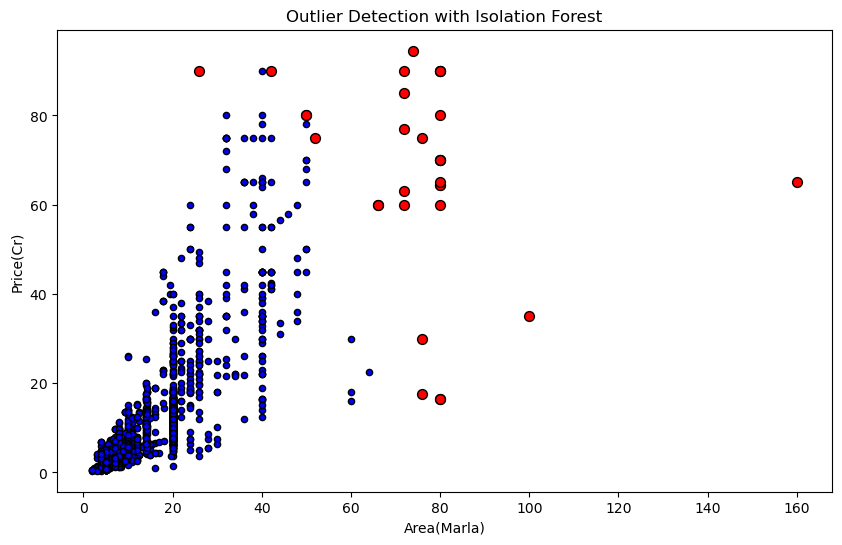

In [91]:
from sklearn.ensemble import IsolationForest

X = houses[['Price(Cr)','Area(Marla)']]
clf = IsolationForest(n_estimators=200,contamination=0.015)

y_pred = clf.fit_predict(X)

is_outlier_forest = y_pred == -1

plt.figure(figsize=(10, 6))
plt.scatter(X.loc[:,'Area(Marla)'],X.loc[:,'Price(Cr)'], color='b', s=20, edgecolor='k')


plt.scatter(X.loc[is_outlier_forest,'Area(Marla)'], X.loc[is_outlier_forest, 'Price(Cr)'], color='r', s=50, edgecolor='k')

plt.title("Outlier Detection with Isolation Forest")
plt.xlabel("Area(Marla)")
plt.ylabel("Price(Cr)")
plt.show()


<Axes: xlabel='Area(Marla)', ylabel='Price(Cr)'>

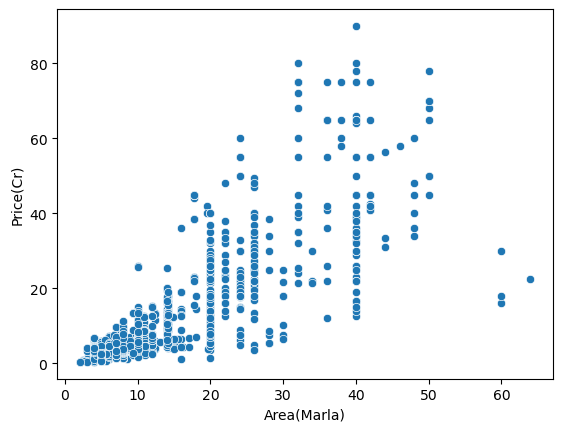

In [92]:
# Scatter plot with out Outliers
sns.scatterplot(data=houses.loc[~is_outlier_forest], x='Area(Marla)',y='Price(Cr)')

In [93]:
# Analyzing the rows having more Area but very less Price
houses[(houses['Area(Marla)']>60)& (houses['Price(Cr)']<40)]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Built in year,Parking Spaces,Floor,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms,Swimming Pool,Storey Unit
791,House,35.0,7.0,100.0,8.0,Gulberg,Live Like the King You Are Meant to Be. Your P...,"Built in year: 2025, Parking Spaces: 8, Double...",NaN,"Broadband Internet Access, Satellite or Cable ...",...,2025.0,8.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
874,House,16.5,6.0,80.0,10.0,Bani Gala,4 Kanal Luxury House 1 Sweet Bed With TV Loung...,"Parking Spaces: 1, Double Glazed Windows, Cent...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,NaN,1.0,NaN,3.0,4.0,1.0,2.0,NaN,NaN,NaN
1135,House,22.5,6.0,64.0,6.0,Bahria Town,Bahira Town Garden City 3.25 Kanal House For S...,"Built in year: 2024, Parking Spaces: 5, Double...","Bedrooms: 6, Bathrooms: 7, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,2024.0,5.0,2.0,6.0,7.0,2.0,1.0,1.0,1.0,1.0
1684,House,17.5,6.0,76.0,6.0,Bahria Town,So if you're interested in buying this propert...,"Built in year, Parking Spaces: 3, Double Glaze...","Bedrooms: 8, Bathrooms: 8, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,3.0,NaN,8.0,8.0,1.0,2.0,1.0,1.0,NaN
1686,House,30.0,6.0,76.0,5.0,Bahria Town,About this rental Featuring an extraordinary 1...,"Built in year: 2025, Parking Spaces: 5, Double...","Bedrooms: 5, Bathrooms: 6, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,2025.0,5.0,2.0,5.0,6.0,2.0,1.0,1.0,1.0,NaN
2683,House,16.5,7.0,80.0,9.0,Bahria Town,Exceptional 4 Kanal 8 Marla Structure for Sale...,"Built in year: 2018, Parking Spaces, Double Gl...","Bedrooms: 8, Bathrooms: 9, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,2018.0,1.0,4.0,8.0,9.0,2.0,3.0,2.0,1.0,NaN


<Axes: ylabel='Area(Marla)'>

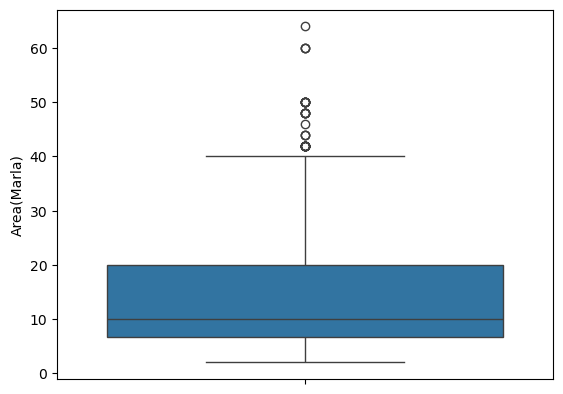

In [94]:
sns.boxplot(data=houses.loc[~is_outlier_forest],y='Area(Marla)',)

*Removing the Outliers*

In [96]:
# Removing the rows where Area(Marla) > 80
houses = houses.loc[~is_outlier_forest,:]

<Axes: ylabel='Area(Marla)'>

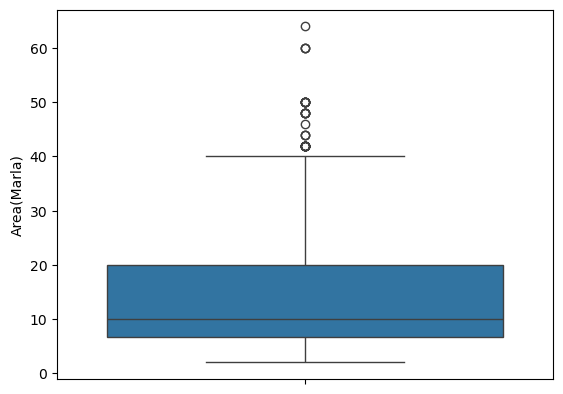

In [97]:
sns.boxplot(houses['Area(Marla)'])

### Bath(s) & Bedroom(s)

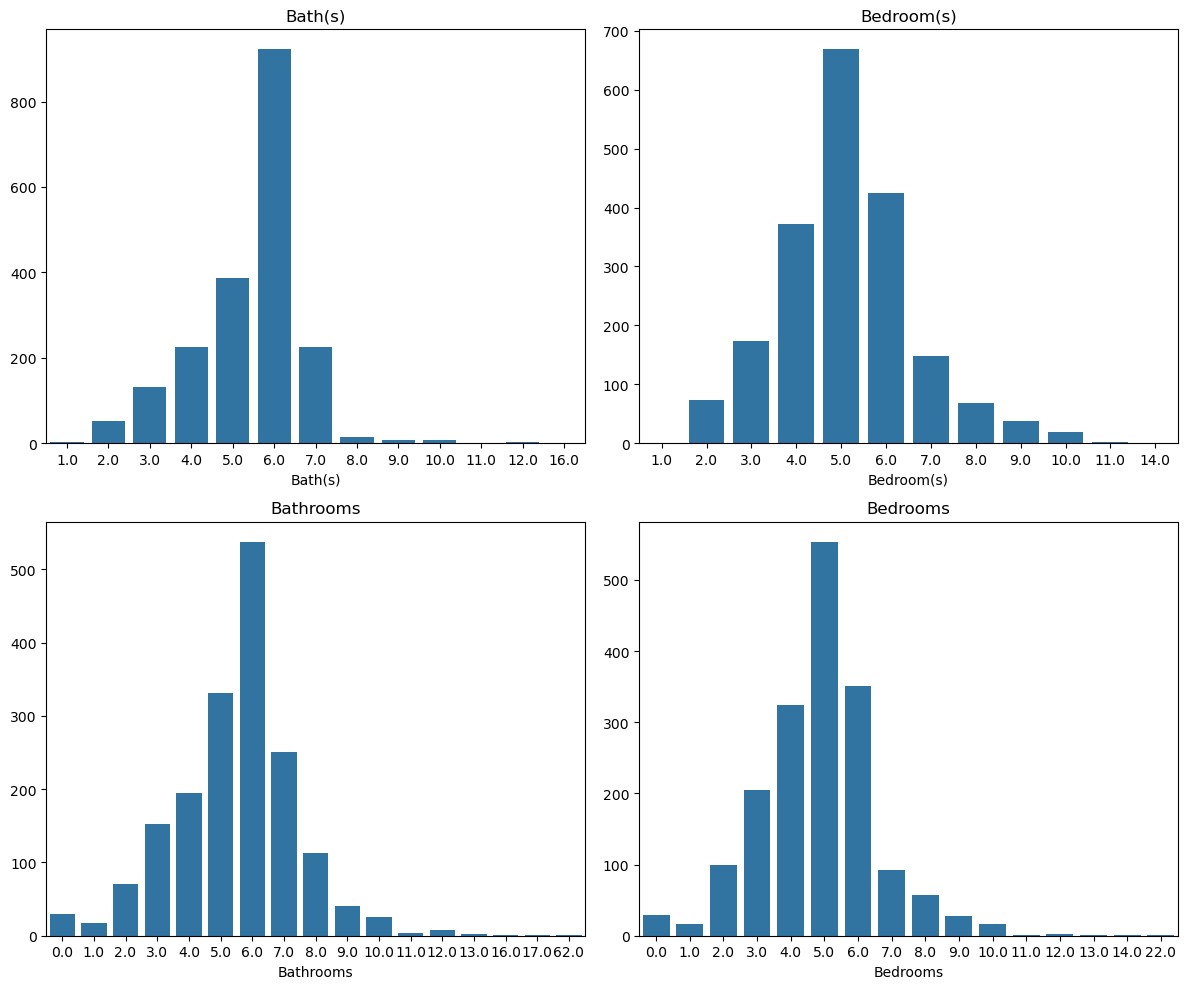

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the figure and a 2x2 grid of axes
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 2. Plot each column on its respective axis
# Row 0, Col 0: Bath(s)
sns.barplot(x=houses['Bath(s)'].value_counts().index, 
            y=houses['Bath(s)'].value_counts().values, 
            ax=axes[0, 0]).set_title('Bath(s)')

# Row 0, Col 1: Bedroom(s)
sns.barplot(x=houses['Bedroom(s)'].value_counts().index, 
            y=houses['Bedroom(s)'].value_counts().values, 
            ax=axes[0, 1]).set_title('Bedroom(s)')

# Row 1, Col 0: Bathrooms
sns.barplot(x=houses['Bathrooms'].value_counts().index, 
            y=houses['Bathrooms'].value_counts().values, 
            ax=axes[1, 0]).set_title('Bathrooms')

# Row 1, Col 1: Bedrooms
sns.barplot(x=houses['Bedrooms'].value_counts().index, 
            y=houses['Bedrooms'].value_counts().values, 
            ax=axes[1, 1]).set_title('Bedrooms')

# 3. Clean up the layout so titles don't overlap
plt.tight_layout()
plt.show()

In [117]:
# Analyzing the Houses having more than 8 Bath(s)
houses[houses['Bath(s)']>=8][['Location','Price(Cr)','Area(Marla)','Bedroom(s)','Bath(s)','Storey Unit','Floor']]

,Location,Price(Cr),Area(Marla),Bedroom(s),Bath(s),Storey Unit,Floor
524,F-10,30.00,28.0,8.0,8.0,NaN,1.0
532,Soan Garden,6.65,20.0,7.0,9.0,2.0,2.0
619,Faisal Town - F-18,10.50,14.0,9.0,10.0,NaN,3.0
635,DHA Defence,11.95,20.0,5.0,8.0,NaN,NaN
777,F-7,42.50,42.0,4.0,10.0,NaN,2.0
778,F-8,65.00,36.0,6.0,8.0,NaN,1.0
779,F-8,41.00,36.0,10.0,12.0,NaN,3.0
898,F-11,18.50,20.0,8.0,8.0,NaN,3.0
1067,F-8,65.00,36.0,9.0,9.0,3.0,3.0
1185,F-10,55.00,40.0,8.0,8.0,3.0,NaN


<Axes: xlabel='Bath(s)', ylabel='Bedroom(s)'>

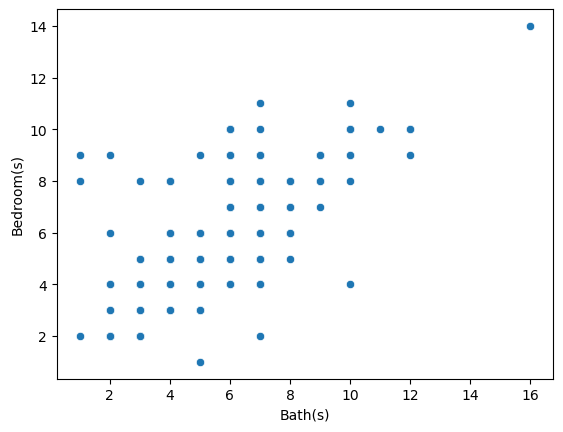

In [118]:
sns.scatterplot(x=houses['Bath(s)'],y=houses['Bedroom(s)'])

*Using Multivaraite Approaches to Detect Outliers*

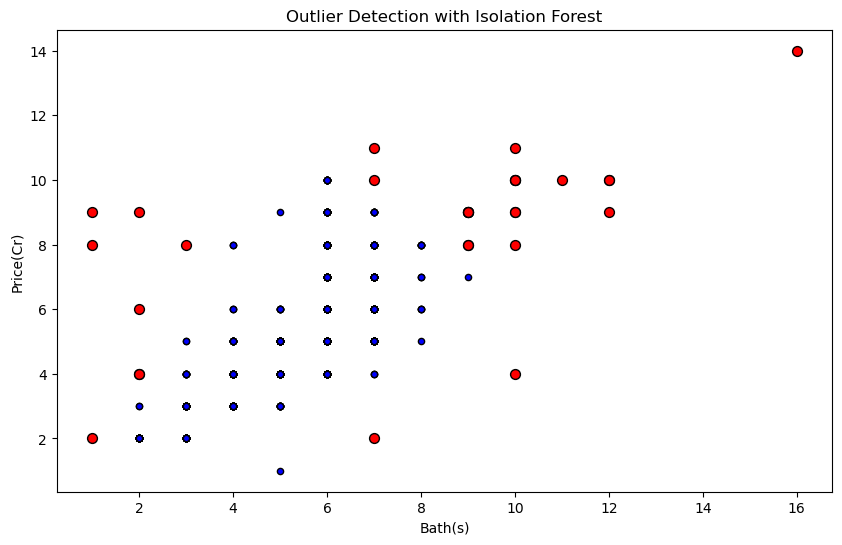

In [120]:
# Using Isolation to determine outliers between Bathrooms and Bedrooms
from sklearn.ensemble import IsolationForest

X = houses[['Bath(s)','Bedroom(s)']]
clf = IsolationForest(n_estimators=200,contamination=0.015)

y_pred = clf.fit_predict(X)

is_outlier_forest = y_pred == -1

plt.figure(figsize=(10, 6))
plt.scatter(X.loc[:,'Bath(s)'],X.loc[:,'Bedroom(s)'], color='b', s=20, edgecolor='k')


plt.scatter(X.loc[is_outlier_forest,'Bath(s)'], X.loc[is_outlier_forest, 'Bedroom(s)'], color='r', s=50, edgecolor='k')

plt.title("Outlier Detection with Isolation Forest")
plt.xlabel("Bath(s)")
plt.ylabel("Price(Cr)")
plt.show()


In [124]:
X.isnull().sum()

Bath(s)       37
Bedroom(s)    30
dtype: int64

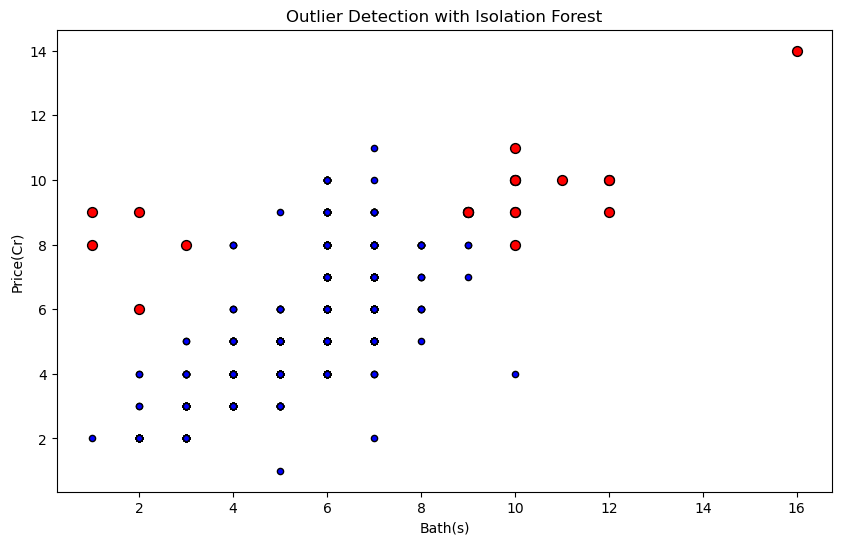

In [134]:
# Using Isolation to determine outliers between Bathrooms and Bedrooms
from sklearn.ensemble import IsolationForest

X = houses[['Bath(s)','Bedroom(s)']]
clf = IsolationForest(n_estimators=200,contamination=0.01)

y_pred = clf.fit_predict(X)

is_outlier_forest = y_pred == -1

plt.figure(figsize=(10, 6))
plt.scatter(X.loc[:,'Bath(s)'],X.loc[:,'Bedroom(s)'], color='b', s=20, edgecolor='k')


plt.scatter(X.loc[is_outlier_forest,'Bath(s)'], X.loc[is_outlier_forest, 'Bedroom(s)'], color='r', s=50, edgecolor='k')

plt.title("Outlier Detection with Isolation Forest")
plt.xlabel("Bath(s)")
plt.ylabel("Price(Cr)")
plt.show()


C:\Users\Wajih\anaconda3\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


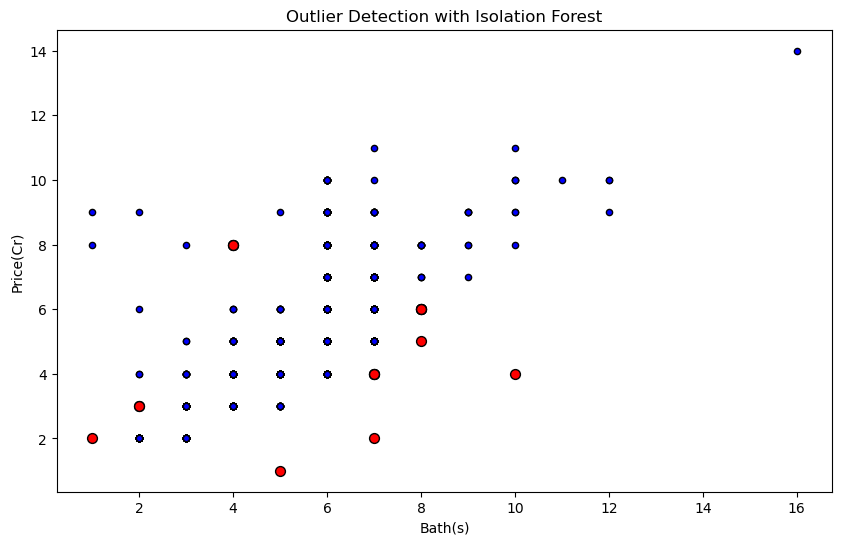

In [135]:
# Using LOF to determine outliers between Bathrooms and Bedrooms

X = houses.dropna(subset=['Bath(s)','Bedroom(s)'],how='any')

from sklearn.neighbors import LocalOutlierFactor

clf = LocalOutlierFactor(contamination = 0.01)
y_pred = clf.fit_predict(X[['Bath(s)','Bedroom(s)']])

is_outlier = y_pred == -1

plt.figure(figsize=(10, 6))
plt.scatter(X.loc[:,'Bath(s)'],X.loc[:,'Bedroom(s)'], color='b', s=20, edgecolor='k')


plt.scatter(X.loc[is_outlier,'Bath(s)'], X.loc[is_outlier, 'Bedroom(s)'], color='r', s=50, edgecolor='k')

plt.title("Outlier Detection with Isolation Forest")
plt.xlabel("Bath(s)")
plt.ylabel("Price(Cr)")
plt.show()

**The Mulitvariate Outlier Detection is not working as it should be, so the best way is to remove those rows where the difference between Bathrooms and Bedrooms is greater than 3**

In [145]:
houses['BedBath_Diff'] = houses['Bedroom(s)'] - houses['Bath(s)']

In [146]:
outlier_rows = houses[(houses['BedBath_Diff']>3)|(houses['BedBath_Diff']<-3)]

In [147]:
outlier_rows[['Area(Marla)','Storey Unit','Floor','Bath(s)','Bedroom(s)']]

,Area(Marla),Storey Unit,Floor,Bath(s),Bedroom(s)
147,40.0,3.0,2.0,5.0,9.0
262,20.0,NaN,3.0,7.0,11.0
290,36.0,NaN,NaN,6.0,10.0
365,20.0,NaN,NaN,4.0,8.0
366,20.0,3.0,3.0,1.0,9.0
630,44.0,NaN,2.0,6.0,10.0
686,20.0,NaN,2.0,6.0,10.0
693,20.0,NaN,2.0,6.0,10.0
777,42.0,NaN,2.0,10.0,4.0
1106,34.0,NaN,NaN,3.0,8.0


<Axes: xlabel='Bath(s)', ylabel='Bedroom(s)'>

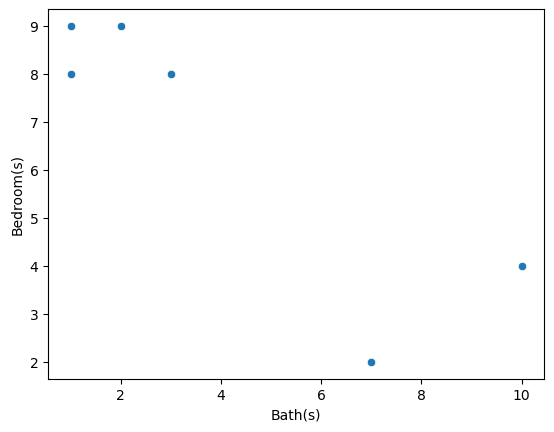

In [144]:
sns.scatterplot(data=houses[(houses['BedBath_Diff']>4)|(houses['BedBath_Diff']<-4)],x='Bath(s)',y='Bedroom(s)')

In [148]:
outlier_rows.shape

(25, 29)

In [152]:
outlier_rows[['Price(Cr)', 'Bath(s)','Area(Marla)', 'Bedroom(s)']]

,Price(Cr),Bath(s),Area(Marla),Bedroom(s)
147,80.00,5.0,40.0,9.0
262,8.00,7.0,20.0,11.0
290,55.00,6.0,36.0,10.0
365,15.00,4.0,20.0,8.0
366,16.00,1.0,20.0,9.0
630,33.50,6.0,44.0,10.0
686,6.10,6.0,20.0,10.0
693,24.00,6.0,20.0,10.0
777,42.50,10.0,42.0,4.0
1106,30.00,3.0,34.0,8.0


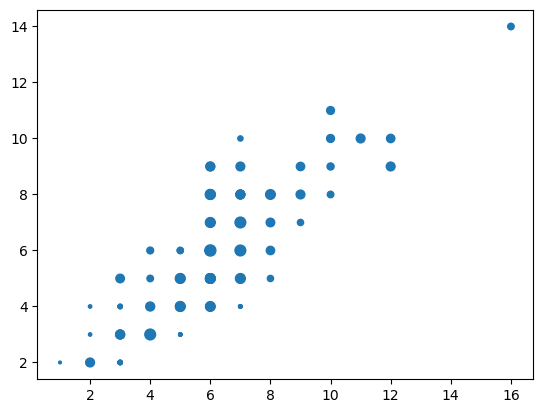

In [156]:
scatter = plt.scatter(data=houses.drop(index=outlier_rows.index),x='Bath(s)',y='Bedroom(s)',s='Area(Marla)')

In [157]:
outlier_rows.index

Index([ 147,  262,  290,  365,  366,  630,  686,  693,  777, 1106, 1184, 1712,
       1786, 1814, 1817, 1840, 1988, 2465, 2557, 2698, 2745, 2780, 2795, 2839,
       2843],
      dtype='int64')

In [158]:
# Removing the outliers rows
houses.drop(outlier_rows.index,inplace=True)

In [159]:
houses.shape

(1995, 29)

### Built in Year

In [160]:
houses['Built in year'].value_counts()

Built in year
2025.0     812
2024.0     246
1.0        121
2023.0     101
2020.0      45
2022.0      41
2015.0      30
2021.0      30
2018.0      22
2010.0      21
2019.0      18
2000.0      16
2017.0      13
2016.0      10
2026.0       9
2005.0       9
1990.0       8
2.0          8
2012.0       8
1998.0       6
1999.0       5
2014.0       5
2027.0       4
2009.0       4
2001.0       3
10.0         3
2002.0       3
20223.0      2
2013.0       2
2008.0       2
225.0        2
2028.0       2
4.0          1
1997.0       1
2250.0       1
1970.0       1
15.0         1
2050.0       1
40.0         1
5.0          1
1996.0       1
2003.0       1
2004.0       1
2011.0       1
1978.0       1
20000.0      1
205.0        1
20242.0      1
3.0          1
1995.0       1
1898.0       1
2007.0       1
1965.0       1
7.0          1
1987.0       1
Name: count, dtype: int64

In [161]:
houses[houses['Built in year']==2050]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Parking Spaces,Floor,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms,Swimming Pool,Storey Unit,BedBath_Diff
537,House,4.2,7.0,7.0,5.0,Gulberg,Block F Near to park 5 bad 7 bath 2 lounge 2 k...,"Built in year: 2050, Parking Spaces: 3, Double...","Bedrooms: 6, Bathrooms: 7, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,3.0,3.0,6.0,7.0,1.0,2.0,1.0,1.0,NaN,-2.0


In [162]:
# There are many Errors, need to correct them manually

year_errors = {
    20242:2024,
    20223:2023,
    225:2025,
    2250:2025,
    2050:2025,
    20000:2000,
    205:2025,
    20242:2024
}

houses['Built in year'] = houses['Built in year'].replace(year_errors)

*Changing the Built in year of Brand New Houses to 2025*

In [163]:
newHouses = houses[(houses['Built in year']< 1800)&(houses['Description'].str.lower().str.contains('brand new'))].index

In [164]:
newHouses 

Index([   0,    6,    8,   34,   35,   49,   50,   67,  288,  440,  441,  451,
        699,  916, 1091, 1228, 1237, 1301, 1305, 1313, 1359, 1364, 1384, 1403,
       1405, 1571, 1678, 1719, 1735, 1782, 1906, 1907, 1974, 1995, 2154, 2215,
       2243, 2257, 2262, 2264, 2502, 2542, 2595, 2701],
      dtype='int64')

In [165]:
houses.loc[newHouses,'Built in year'] = 2025

*Changing the value to Nan where Built in year is misleading (e.g where there is values less than 1800)*

In [166]:
Nanyear = houses[houses['Built in year']<1800].index

houses.loc[Nanyear,'Built in year'] = np.nan

In [167]:
houses['Built in year'].value_counts()

Built in year
2025.0    861
2024.0    247
2023.0    103
2020.0     45
2022.0     41
2015.0     30
2021.0     30
2018.0     22
2010.0     21
2019.0     18
2000.0     17
2017.0     13
2016.0     10
2026.0      9
2005.0      9
1990.0      8
2012.0      8
1998.0      6
1999.0      5
2014.0      5
2027.0      4
2009.0      4
2001.0      3
2002.0      3
2013.0      2
2008.0      2
2028.0      2
1997.0      1
1970.0      1
1996.0      1
2003.0      1
2004.0      1
2011.0      1
1978.0      1
1995.0      1
1898.0      1
2007.0      1
1965.0      1
1987.0      1
Name: count, dtype: int64

### Parking Spaces

<Axes: xlabel='Parking Spaces', ylabel='count'>

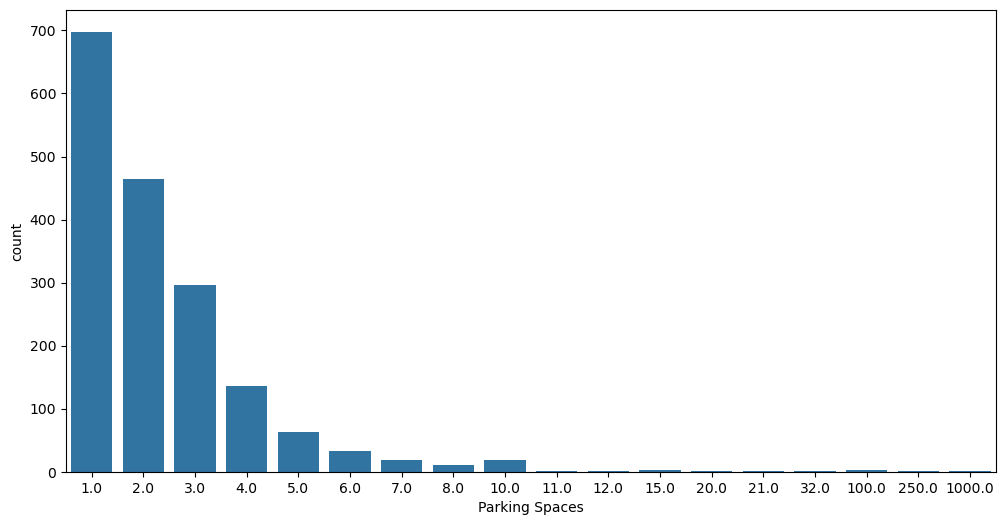

In [170]:
plt.figure(figsize=(12,6))
sns.barplot(houses['Parking Spaces'].value_counts())

In [171]:
houses['Parking Spaces'].value_counts()

Parking Spaces
1.0       698
2.0       464
3.0       296
4.0       136
5.0        63
6.0        33
10.0       19
7.0        18
8.0        11
100.0       2
15.0        2
20.0        1
11.0        1
21.0        1
250.0       1
32.0        1
1000.0      1
12.0        1
Name: count, dtype: int64

In [172]:
houses[houses['Parking Spaces']>=5]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Parking Spaces,Floor,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms,Swimming Pool,Storey Unit,BedBath_Diff
37,House,19.0,7.0,20.0,9.0,F-11,Corner House For Sale 50/90 Triple Story Prime...,"Built in year: 1998, Parking Spaces: 6, Double...","Bedrooms: 9, Bathrooms: 10, Servant Quarters: ...","Broadband Internet Access, Satellite or Cable ...",...,6.0,3.0,9.0,10.0,1.0,2.0,1.0,1.0,3.0,2.0
41,House,19.0,6.0,24.0,8.0,G-10,outstanding location Beautiful House 60/90 600...,"Built in year: 1997, Parking Spaces: 6, Double...","Bedrooms: 8, Bathrooms: 8, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,6.0,3.0,8.0,8.0,2.0,2.0,2.0,1.0,3.0,2.0
69,House,26.5,6.0,20.0,7.0,D-12,Luxurious 3-Story Kanal House for Sale Key Fea...,"Built in year: 2025, Parking Spaces: 6, Double...","Bedrooms: 7, Bathrooms: 7, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,6.0,3.0,7.0,7.0,1.0,2.0,1.0,NaN,3.0,1.0
94,House,58.0,6.0,38.0,5.0,E-7,Details; 1. Size 80 x 105 : 975 sqyrds. 2. Sun...,"Built in year: 1990, Parking Spaces: 10, Doubl...","Bedrooms: 5, Bathrooms: 6, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,10.0,2.0,5.0,6.0,2.0,1.0,1.0,1.0,1.0,-1.0
112,House,10.0,5.0,20.0,5.0,DHA Defence,We offer you just the right House to purchase....,"Built in year: 2024, Parking Spaces: 5, Double...","Bedrooms: 5, Bathrooms: 5, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,5.0,2.0,5.0,5.0,2.0,2.0,2.0,1.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2824,House,39.0,6.0,26.0,6.0,F-7,Fully Renovated House Available For Sale In F7...,"Built in year: 2024, Parking Spaces: 5, Double...","Bedrooms: 6, Bathrooms: 6, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,5.0,2.0,6.0,6.0,2.0,2.0,2.0,1.0,NaN,0.0
2832,House,65.0,3.0,38.0,3.0,E-7,When you have a property of 933 Square Yards w...,"Built in year: 2025, Parking Spaces: 6, Double...","Bedrooms: 3, Bathrooms: 3, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,6.0,2.0,3.0,3.0,1.0,1.0,1.0,1.0,NaN,0.0
2838,House,65.0,11.0,40.0,10.0,F-7,Details: 1. Size 100 x 90 = 1000 sqyrds. 2. su...,"Parking Spaces: 6, Double Glazed Windows, Cent...","Bedrooms: 10, Bathrooms: 11, Servant Quarters:...","Broadband Internet Access, Satellite or Cable ...",...,6.0,3.0,10.0,11.0,2.0,2.0,2.0,NaN,NaN,-1.0
2853,House,34.0,8.0,28.0,7.0,F-7,house available for sale in f7 demoliable hous...,"Built in year: 2024, Parking Spaces: 5, Double...","Bedrooms: 7, Bathrooms: 8, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,5.0,2.0,7.0,8.0,2.0,2.0,1.0,1.0,NaN,-1.0


<Axes: xlabel='Area(Marla)', ylabel='Parking Spaces'>

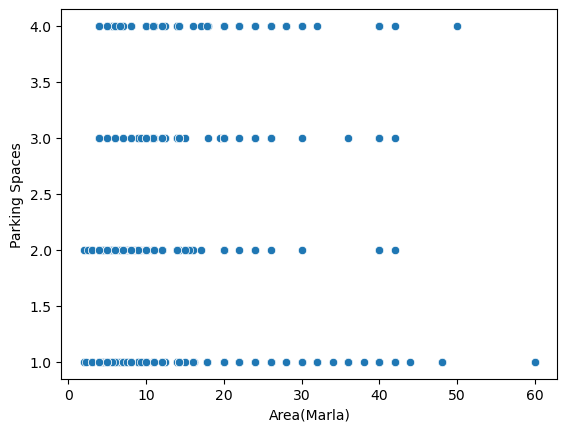

In [173]:
sns.scatterplot(houses[houses['Parking Spaces']<=4],x='Area(Marla)',y='Parking Spaces')

*By looking at this chart, we can deduce that the Parking Space column is misleading even though it looks useful.*

The reason could be human error, the agent exaggerated this feature.

**So the best thing is to drop it to avoid any error in the model**

### Floor and Storey Unit

*Storey Unit is more reliable because we directly extracted from the description column.*

### What to do:

1. Use Storey Unit as the Floor column
2. And use Floor column where Storey Unit information is missing.

<Axes: xlabel='Floor', ylabel='count'>

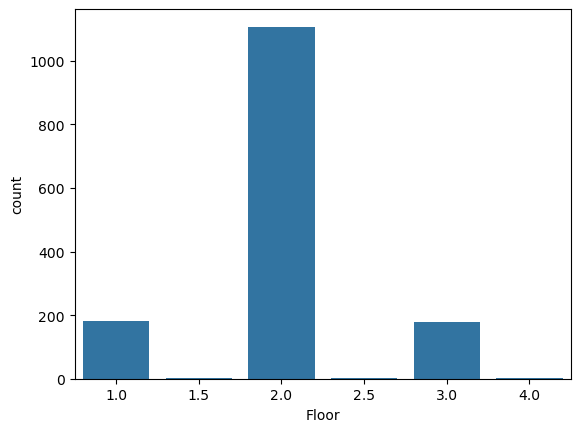

In [175]:
sns.barplot(houses['Floor'].value_counts())

<Axes: xlabel='Storey Unit', ylabel='count'>

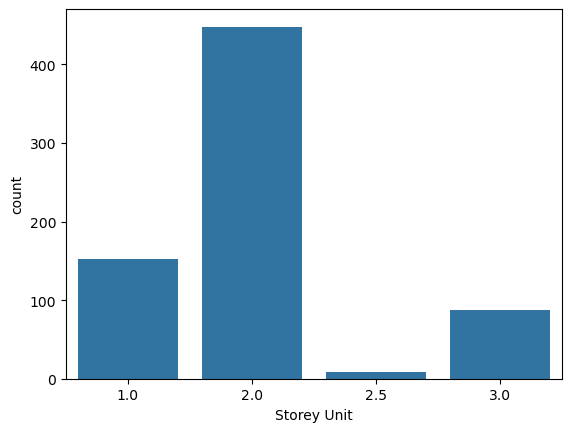

In [176]:
sns.barplot(houses['Storey Unit'].value_counts())

In [177]:
Nanstorey = houses['Storey Unit'].isnull()[houses['Storey Unit'].isnull()==True].index

In [178]:
houses.loc[Nanstorey,'Storey Unit'] = houses.loc[Nanstorey,'Floor']

<Axes: xlabel='Storey Unit', ylabel='count'>

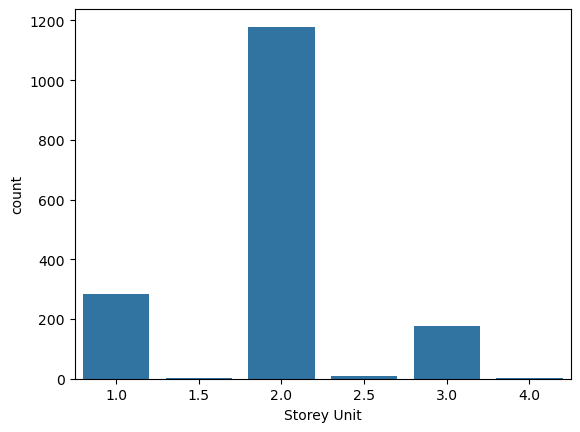

In [179]:
sns.barplot(houses['Storey Unit'].value_counts())

### Servant Quarter

In [183]:
houses['Servant Quarters'].value_counts()

Servant Quarters
1.0     964
2.0     397
0.0     178
3.0      21
8.0       4
4.0       4
6.0       2
12.0      2
7.0       1
Name: count, dtype: int64

<Axes: xlabel='Servant Quarters', ylabel='count'>

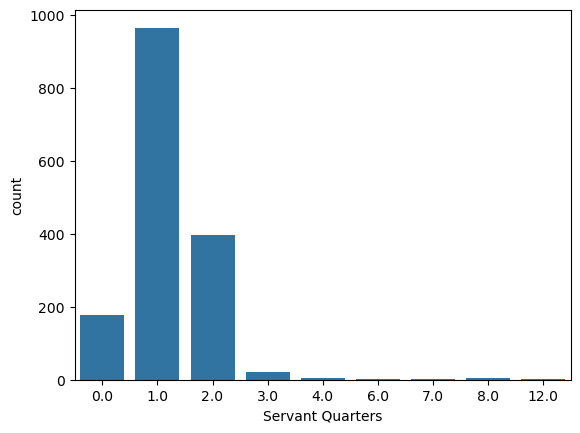

In [184]:
sns.barplot(houses['Servant Quarters'].value_counts())

*Setting to Nan for equal to 0 and 2+*

In [185]:
Nanservantquar = houses[~houses['Servant Quarters'].isin([1,2])].index

In [186]:
houses.loc[Nanservantquar,'Servant Quarters'] = np.nan

### Store Rooms

<Axes: xlabel='Store Rooms', ylabel='count'>

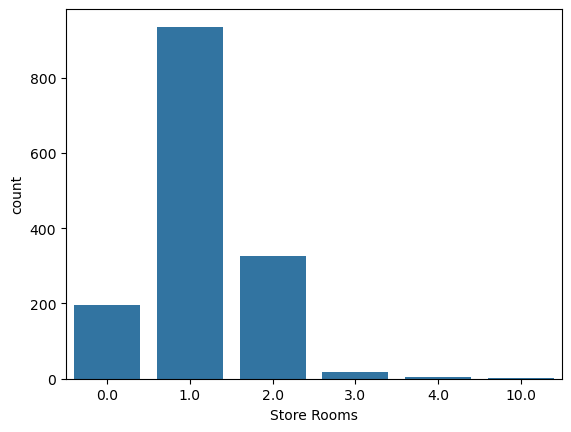

In [188]:
sns.barplot(houses['Store Rooms'].value_counts())

*Setting to Nan for equal to 0 and 2+*

In [189]:
Nanstore = houses[~houses['Store Rooms'].isin([1,2,3])].index

In [190]:
houses.loc[Nanstore,'Store Rooms'] = np.nan

### Kitchens 

<Axes: xlabel='Kitchens', ylabel='count'>

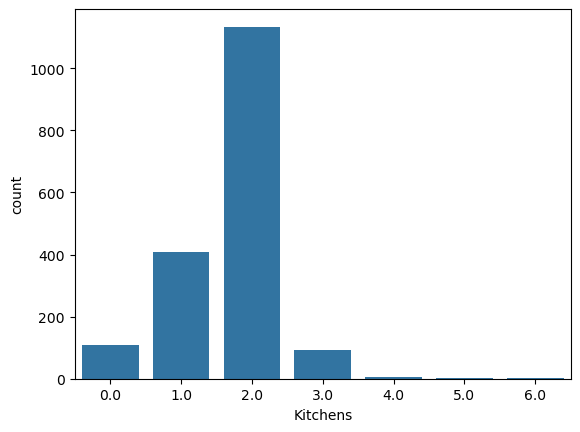

In [192]:
sns.barplot(houses['Kitchens'].value_counts())

In [193]:
houses[houses['Kitchens']>3].index

Index([456, 545, 566, 977, 2142, 2716, 2729, 2794, 2865], dtype='int64')

In [194]:
houses.loc[2865]

Type                                                                                 House
Price(Cr)                                                                             16.0
Bath(s)                                                                               16.0
Area(Marla)                                                                           22.0
Bedroom(s)                                                                            14.0
Location                                                                              G-11
Description                              Kanal+ Big and Elegant House is available for ...
Amenities: Main Features                 Built in year: 2025, Parking Spaces: 6, Floori...
Amenities: Rooms                         Bedrooms: 14, Bathrooms: 16, Servant Quarters:...
Amenities: Business and Communication    Broadband Internet Access, Satellite or Cable ...
Amenities: Community Features             Community Lawn or Garden, Kids Play Area, Mosque

In [195]:
houses['Description'].loc[2865]

'Kanal+ Big and Elegant House is available for Sale in G11 Islamabad Size 60x90 14 Bedrooms 16 Washrooms 6 Drwaing Dinings 6 TVLs 6 Kitchens 3 Gates 4 Gas Meters 4 Electric Meters Ample parking space Corner with extra land and basement Wide streets Near by Masjid and Market CDA Transfer P. S. : Pictures are real'

*Upon further analyzing, Kitchens > 3 doesn't seems outlier, so we will keep them*

*However changing the Kitchens = 0 to Nan*

In [196]:
Nankitchens = houses[~houses['Kitchens'].isin([1,2])].index

In [197]:
houses.loc[Nankitchens,'Kitchens'] = np.nan

In [282]:
# Saving the file

In [199]:
houses.to_csv('houses_outlier_handled.csv')